# QQP Model Comparison: S4 vs LMU Across Data Fractions

This notebook compares S4 and LMU models trained on different fractions of the QQP dataset.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4


## Load Test Results

Load test_results.json from each run folder for both S4 and LMU models across all data fractions.


In [2]:
from src.eval.compare import load_all_experiments

base_dir = "./runs"
models = ['s4', 'lmu']
fractions = [0.1, 0.25, 0.5, 1.0]
task_name = "qqp"

print("="*60)
print("LOADING QQP EXPERIMENT RESULTS")
print("="*60)
print()

all_results = load_all_experiments(
    base_dir=base_dir,
    models=models,
    fractions=fractions,
    task_name=task_name
)

print()
print("="*60)
print("LOADING COMPLETE")
print("="*60)

for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"{model.upper()}: Loaded {n_loaded}/{len(fractions)} experiments")

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


LOADING QQP EXPERIMENT RESULTS

Loading S4 @ 10%: qqp_s4_task_frac_10
Loading S4 @ 25%: qqp_s4_task_frac_25
Loading S4 @ 50%: qqp_s4_task_frac_50
Loading S4 @ 100%: qqp_s4_task
Loading LMU @ 10%: qqp_lmu_task_frac_10
Loading LMU @ 25%: qqp_lmu_task_frac_25
Loading LMU @ 50%: qqp_lmu_task_frac_50
Loading LMU @ 100%: qqp_lmu_task

LOADING COMPLETE
S4: Loaded 4/4 experiments
LMU: Loaded 4/4 experiments


In [3]:
from src.eval.compare import create_test_comparison_table

print()

test_comparison_df = create_test_comparison_table(
    all_results,
    metrics=['accuracy', 'loss', 'f1_score']
)

pd.options.display.float_format = '{:.4f}'.format


print("\n" + "="*60)
print("BEST MODEL PER DATA FRACTION")
print("="*60)
for pct in sorted(test_comparison_df['data_pct'].unique()):
    subset = test_comparison_df[test_comparison_df['data_pct'] == pct]
    best_idx = subset['accuracy'].idxmax()
    best_row = subset.loc[best_idx]
    print(f"\n{pct}% data: {best_row['model']} (Accuracy: {best_row['accuracy']*100:.2f}%)")

print()
test_comparison_df



BEST MODEL PER DATA FRACTION

10% data: LMU (Accuracy: 74.02%)

25% data: S4 (Accuracy: 76.15%)

50% data: S4 (Accuracy: 79.04%)

100% data: S4 (Accuracy: 80.71%)



,model,data_pct,accuracy,loss,f1_score,num_samples
0,LMU,10,0.7402,0.5466,0.6034,40435
1,LMU,25,0.7520,0.5225,0.6336,40435
2,LMU,50,0.7742,0.4905,0.6598,40435
3,LMU,100,0.7873,0.4713,0.6903,40435
4,S4,10,0.7355,0.5381,0.5854,40435
5,S4,25,0.7615,0.5186,0.6630,40435
6,S4,50,0.7904,0.5090,0.7062,40435
7,S4,100,0.8071,0.4496,0.7104,40435


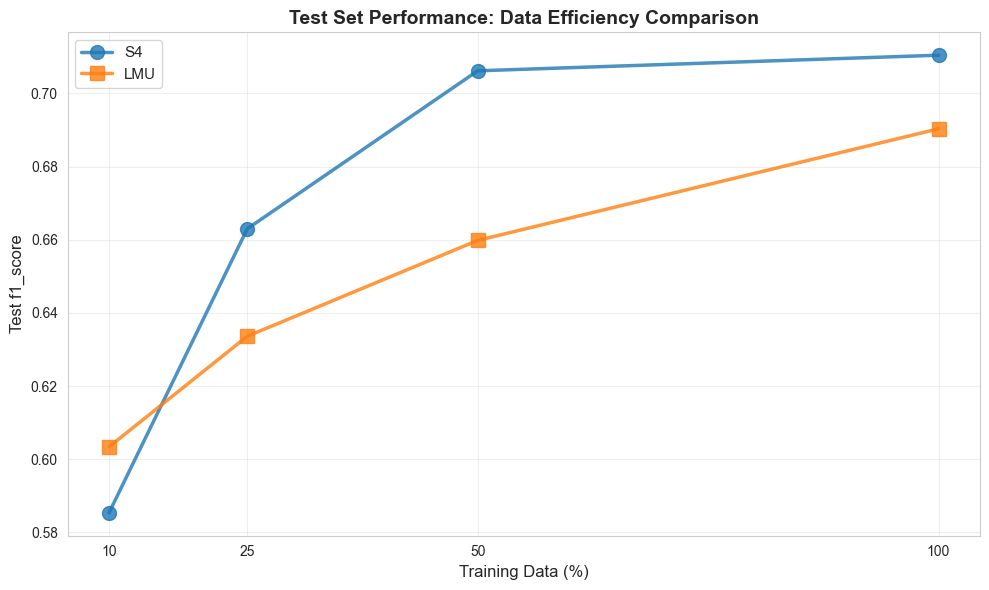

In [4]:
from src.eval.compare import plot_test_data_efficiency

plot_test_data_efficiency(
    all_results,
    metric_key='f1_score',
    ylabel='Test f1_score'
)

## Visualization: Test Loss Comparison

Compare test loss of S4 and LMU across different data fractions.


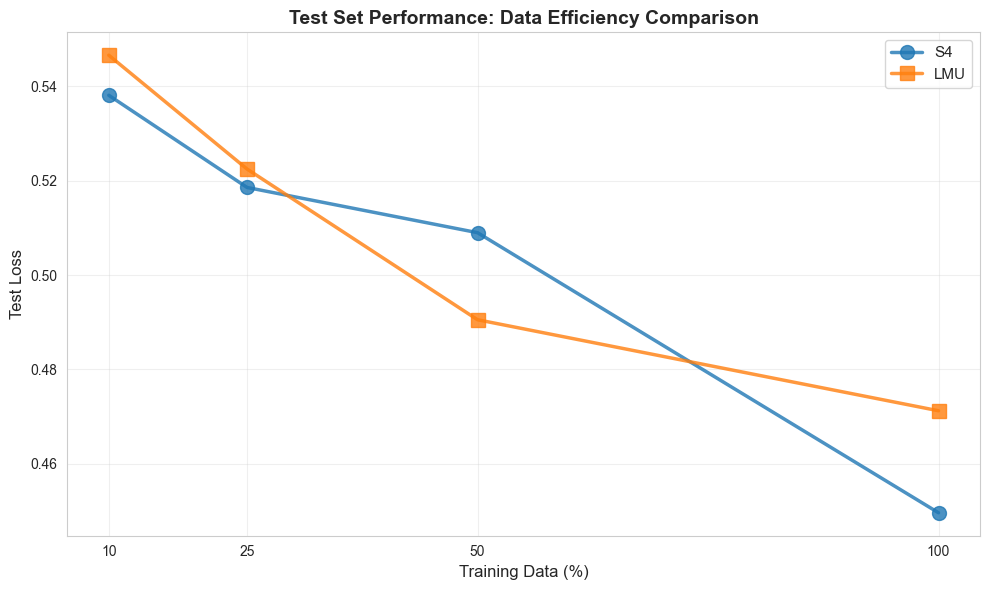

In [5]:
plot_test_data_efficiency(
    all_results,
    metric_key='loss',
    ylabel='Test Loss'
)

## Bar Chart Comparison

Side-by-side comparison of test accuracy for each data fraction.


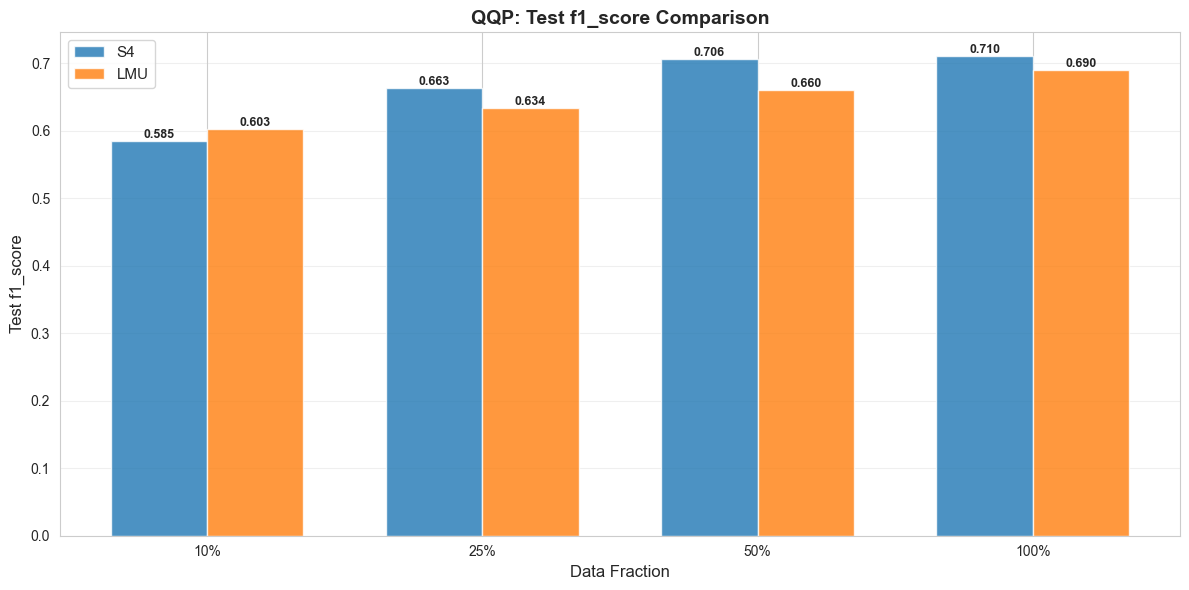

In [6]:
from src.eval.compare import plot_test_metric_comparison

plot_test_metric_comparison(
    all_results,
    metric_key='f1_score',
    title='QQP: Test f1_score Comparison',
    ylabel='Test f1_score',
)

### Heatmap Visualization

Visual comparison of test accuracy across models and data fractions.


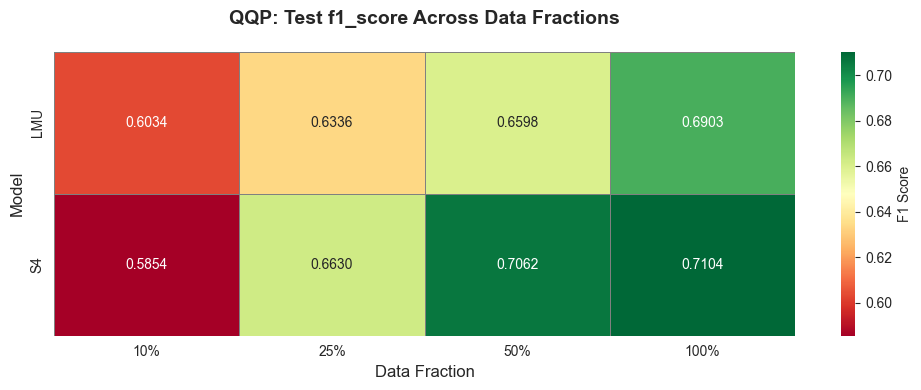

In [7]:
from src.eval.compare import plot_performance_heatmap

plot_performance_heatmap(
    all_results,
    metric_key='f1_score',
    title='QQP: Test f1_score Across Data Fractions',
    annot_format='.4f'
)